# EDA in different regions 

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/cleaned/Global_Superstore_cleaned.csv", sep=",", encoding="latin1")   #load the cleaned dataset, not the raw one

## Sales Analysis

In [3]:
# Which category contributes most sales?
df.groupby("category")["sales"].sum().sort_values(ascending=False)

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

In [4]:
# Which sub-category contributes most sales?
df.groupby("sub_category")["sales"].sum().sort_values(ascending=False)

sub_category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: sales, dtype: float64

In [5]:
# How do sales vary over time?
df.groupby("order_year")["sales"].sum()

order_year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: sales, dtype: float64

In [6]:
# Sales by category

# Which category generates the highest sales?
# Is the difference significant?

sales_by_category = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_by_category

category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: sales, dtype: float64

<Axes: title={'center': 'Sales Trend by Category'}, xlabel='order_year'>

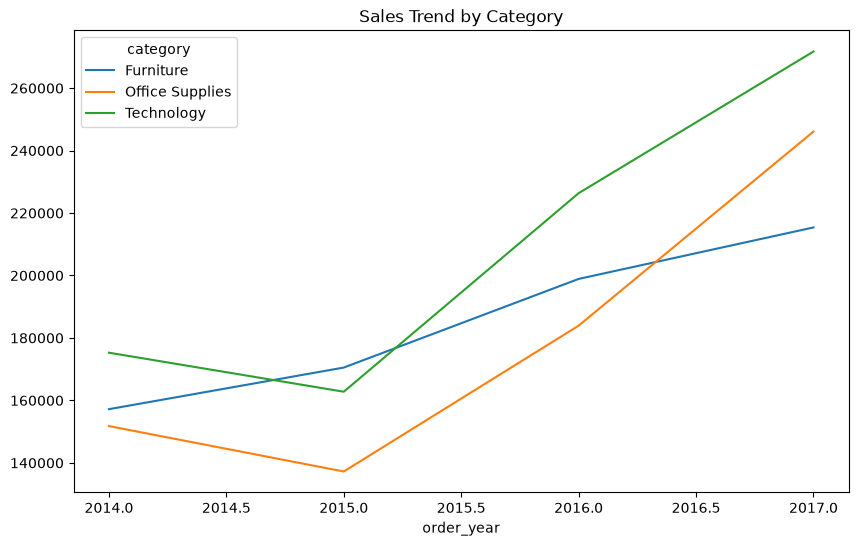

In [36]:
# Sales Trend by Category
sales_trend_by_category = (
    df.groupby(["order_year", "category"])["sales"]
      .sum()
      .unstack()
)
sales_trend_by_category.plot(kind="line", figsize=(10, 6), title="Sales Trend by Category")

In [ ]:
# minimum and maximum year
df["order_year"].min()      #2014
df["order_year"].max()      #2017

np.int64(2017)

## Profit Analysis

In [7]:
# Which categories are profitable?
df.groupby("category")["profit"].sum().sort_values(ascending=False)

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

In [8]:
# Which sub-categories lose money?
df.groupby("sub_category")["profit"].sum().sort_values(ascending=True)

sub_category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: profit, dtype: float64

In [9]:
# Profit By category

# Does the category with the highest sales also have the highest profit?
profit_by_category = (
    df.groupby("category")["profit"]
      .sum()
      .sort_values(ascending=False)
)

profit_by_category

category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: profit, dtype: float64

In [10]:
# Profit by sub-category

profit_by_subcategory = (
    df.groupby("sub_category")["profit"]
      .sum()
      .sort_values()
)

profit_by_subcategory

sub_category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: profit, dtype: float64

## Customer Analysis

In [17]:
# Which segment generates most revenue?
df.groupby("segment")["sales"].sum().sort_values(ascending=False)

segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: sales, dtype: float64

In [19]:
# highest profit segment
df.groupby("segment")["profit"].sum()

segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: profit, dtype: float64

In [ ]:
# Who are the top customers by sales?
df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64

In [20]:
# top customers by profit
df.groupby("customer_name")["profit"].sum().sort_values(ascending=False).head(10)

customer_name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: profit, dtype: float64

## Geographic Analysis

In [ ]:
# Which states drive revenue?
df.groupby("state")["sales"].sum().sort_values(ascending=False)

state
California              457687.6315
New York                310876.2710
Texas                   170188.0458
Washington              138641.2700
Pennsylvania            116511.9140
Florida                  89473.7080
Illinois                 80166.1010
Ohio                     78258.1360
Michigan                 76269.6140
Virginia                 70636.7200
North Carolina           55603.1640
Indiana                  53555.3600
Georgia                  49095.8400
Kentucky                 36591.7500
New Jersey               35764.3120
Arizona                  35282.0010
Wisconsin                32114.6100
Colorado                 32108.1180
Tennessee                30661.8730
Minnesota                29863.1500
Massachusetts            28634.4340
Delaware                 27451.0690
Maryland                 23705.5230
Rhode Island             22627.9560
Missouri                 22205.1500
Oklahoma                 19683.3900
Alabama                  19510.6400
Oregon                

In [ ]:
# Which regions are underperforming?
df.groupby("region")["sales"].sum().sort_values(ascending=True)

region
South      391721.9050
Central    501239.8908
East       678781.2400
West       725457.8245
Name: sales, dtype: float64

In [21]:
# Highest Profit State
df.groupby("state")["profit"].sum().sort_values(ascending=False)

state
California              76381.3871
New York                74038.5486
Washington              33402.6517
Michigan                24463.1876
Virginia                18597.9504
Indiana                 18382.9363
Georgia                 16250.0433
Kentucky                11199.6966
Minnesota               10823.1874
Delaware                 9977.3748
New Jersey               9772.9138
Wisconsin                8401.8004
Rhode Island             7285.6293
Maryland                 7031.1788
Massachusetts            6785.5016
Missouri                 6436.2105
Alabama                  5786.8253
Oklahoma                 4853.9560
Arkansas                 4008.6871
Connecticut              3511.4918
Nevada                   3316.7659
Mississippi              3172.9762
Utah                     2546.5335
Vermont                  2244.9783
Louisiana                2196.1023
Nebraska                 2037.0942
Montana                  1833.3285
South Carolina           1769.0566
New Hampshire 

In [22]:
# Best Performing Region
df.groupby("region")["profit"].sum().sort_values(ascending=False)

region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: profit, dtype: float64

## Discount Analysis

In [23]:
# average discount
df["discount"].mean()

np.float64(0.1562027216329798)

In [24]:
# average discount by category
df.groupby("category")["discount"].mean().sort_values(ascending=False)  

category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: discount, dtype: float64

In [ ]:
# Does higher discount increase sales?
df[["discount", "sales"]].corr()

,discount,sales
discount,1.00000,-0.02819
sales,-0.02819,1.00000


<Axes: xlabel='discount', ylabel='sales'>

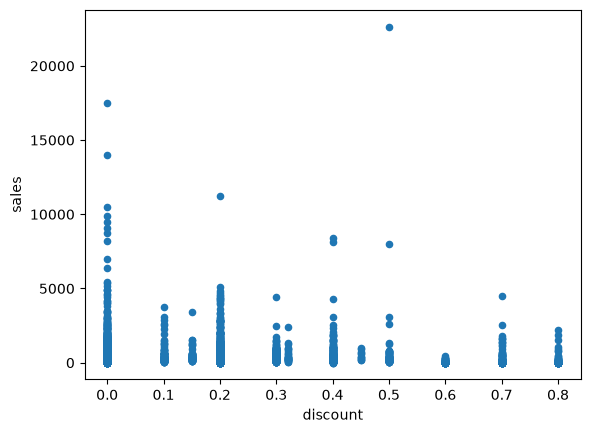

In [25]:
# Relationship between discount and sales
df.plot(x="discount", y="sales", kind="scatter")

In [ ]:
# Does higher discount reduce profits?
df[["discount", "profit"]].corr()

,discount,profit
discount,1.000000,-0.219487
profit,-0.219487,1.000000


<Axes: xlabel='discount', ylabel='profit'>

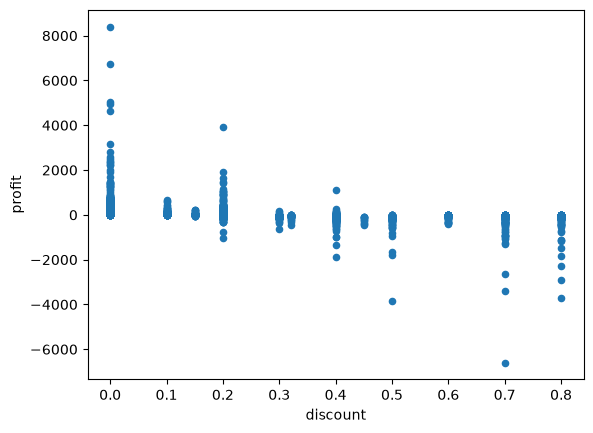

In [26]:
# relationship between discount and profit
df.plot(x="discount", y="profit", kind="scatter")

In [27]:
# categories receiving highest discounts
df.groupby("category")["discount"].mean().sort_values(ascending=False)

category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: discount, dtype: float64

## Shipping Analysis

In [ ]:
# How do delivery days vary by ship mode?
df.groupby("ship_mode")["delivery_days"].mean()

ship_mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: delivery_days, dtype: float64

In [ ]:
# which shipping mode has the shortest delivery time
df.groupby("ship_mode")["delivery_days"].mean().sort_values()

ship_mode
Same Day          0.044199
First Class       2.182705
Second Class      3.238046
Standard Class    5.006535
Name: delivery_days, dtype: float64

In [ ]:
# which shipping mode is used the most
df.groupby("ship_mode")["order_id"].count().sort_values(ascending=False)

ship_mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: order_id, dtype: int64

In [29]:
# shipping mode with the highest sales
df.groupby("ship_mode")["sales"].sum().sort_values(ascending=False)

ship_mode
Standard Class    1.358216e+06
Second Class      4.591936e+05
First Class       3.514284e+05
Same Day          1.283631e+05
Name: sales, dtype: float64

In [30]:
# shipping mode with the highest profit
df.groupby("ship_mode")["profit"].sum().sort_values(ascending=False)

ship_mode
Standard Class    164088.7875
Second Class       57446.6354
First Class        48969.8399
Same Day           15891.7589
Name: profit, dtype: float64

In [34]:
# average delivery time by shipping mode
df.groupby("ship_mode")["delivery_days"].mean()

ship_mode
First Class       2.182705
Same Day          0.044199
Second Class      3.238046
Standard Class    5.006535
Name: delivery_days, dtype: float64

## Category Level Summary

In [ ]:
category_summary = (
    df.groupby("category")
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          avg_discount=("discount", "mean")
      )
      .sort_values(by="total_sales", ascending=False)
)

category_summary

,total_sales,total_profit,total_quantity,avg_discount
category,,,,
Technology,836154.0330,145454.9481,6939,0.132323
Furniture,741999.7953,18451.2728,8028,0.173923
Office Supplies,719047.0320,122490.8008,22906,0.157285


## Sub Category Level Summary Table

In [ ]:
subcategory_summary = (
    df.groupby("sub_category")
      .agg(
          total_sales=("sales", "sum"),
          total_profit=("profit", "sum"),
          total_quantity=("quantity", "sum"),
          avg_discount=("discount", "mean")
      )
      .sort_values(by="total_sales", ascending=False)
)

subcategory_summary

,total_sales,total_profit,total_quantity,avg_discount
sub_category,,,,
Phones,330007.0540,44515.7306,3289,0.154556
Chairs,328449.1030,26590.1663,2356,0.170178
Storage,223843.6080,21278.8264,3158,0.074704
Tables,206965.5320,-17725.4811,1241,0.261285
Binders,203412.7330,30221.7633,5974,0.372292
Machines,189238.6310,3384.7569,440,0.306087
Accessories,167380.3180,41936.6357,2976,0.078452
Copiers,149528.0300,55617.8249,234,0.161765
Bookcases,114879.9963,-3472.5560,868,0.211140
